In [3]:
import sys
!{sys.executable} -m pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [4]:
import torch
import numpy as np
import pandas as pd
import cv2
import shapely

print("All packages loaded successfully")
print("Torch version:", torch.__version__)

All packages loaded successfully
Torch version: 2.8.0


In [1]:
import sys
!{sys.executable} model/OOD_supervised_contrastive_classifier.py

Loading OOD data...

Split sizes:
split
OOD_train    166544
OOD_hold      53403
OOD_test      46833
Name: count, dtype: int64

Train label distribution:
damage_label
no-damage       120576
major-damage     17327
minor-damage     17063
destroyed        11578
Name: count, dtype: int64

Test label distribution:
damage_label
no-damage       37859
destroyed        6089
major-damage     2260
minor-damage      625
Name: count, dtype: int64

Hold label distribution:
damage_label
no-damage       38388
minor-damage     8428
destroyed        3558
major-damage     3029
Name: count, dtype: int64

Image overlap check:
OOD_train intersection OOD_test: 0
OOD_train intersection OOD_hold: 0
OOD_test intersection OOD_hold: 0

Location overlap check:
OOD_train intersection OOD_test: 0
OOD_train intersection OOD_hold: 0
OOD_test intersection OOD_hold: 0

PASS: no image or location overlap.

Using device: mps

Starting ResNet50 supervised contrastive pretraining...
Contrastive Epoch 1/5: 100%|███| 5205/5205

# Model Performance Analysis and Interpretation

## 1. Training Dynamics

The training process shows stable behavior without strong overfitting.

Training loss decreases steadily from 0.5711 to 0.4409, while OOD test performance remains relatively constant:

* Test Macro F1 ranges between 0.33 and 0.37
* Best performance is reached at epoch 5 (0.3686)

This suggests that:

* the model does not significantly overfit
* performance plateaus early
* additional epochs are unlikely to improve results

---

## 2. Overall Performance

The final performance of the model is:

| Split | Macro F1 |
| ----- | -------- |
| Test  | 0.3686   |
| Hold  | 0.3662   |

Key observations:

* performance is consistent across test and holdout splits
* there is almost no performance drop
* this indicates stable generalization across unseen locations

---

## 3. Class-wise Performance

The model shows strong variation across classes.

### No damage

* Test F1: 0.5382  
* Hold F1: 0.6948  

Performance is solid but reduced compared to standard baselines due to increased confusion with damage classes.

---

### Minor damage

* Test F1: 0.0401  
* Hold F1: 0.3221  

Performance is very low on the test set but improves on the holdout set.

This indicates:

* sensitivity to class imbalance
* difficulty learning subtle damage patterns

---

### Major damage

* Test F1: 0.1503  
* Hold F1: 0.1524  

Performance is low and stable.

This class remains difficult due to visual ambiguity and overlap with other damage levels.

---

### Destroyed

* Test F1: 0.7458  
* Hold F1: 0.2955  

Strong performance on test but a clear drop on hold.

This suggests:

* good learning of severe damage features
* limited generalization across locations

---

## 4. Precision Recall Trade-off

The model exhibits a strong recall bias:

* damage classes are heavily over-predicted
* recall is relatively high
* precision is low, especially for minor and major damage

This means:

* the model tends to detect damage aggressively
* many predictions are false positives

---

## 5. Effect of Class Weights

Class weights used:

[0.3453, 2.4401, 2.4030, 3.5961]

### Positive effects

* improved recall for minority classes
* better detection of damaged buildings

### Negative effects

* low precision for minority classes
* over-prediction of damage categories

---

## 6. Generalization to Holdout Data

The near-identical performance:

* Test Macro F1: 0.3686  
* Hold Macro F1: 0.3662  

indicates stable generalization across unseen locations.

This confirms that:

* the OOD split is well constructed
* evaluation results are reliable

---

## 7. Limitations

The experiment highlights several limitations:

* low precision for damage classes
* strong over-prediction behavior
* instability for underrepresented classes
* difficulty distinguishing between damage levels

These results show that:

* representation learning improves detection
* but does not fully solve OOD generalization

---

## Final Interpretation

The contrastive model increases sensitivity to damage, improving recall compared to baseline models.

However, this comes at the cost of reduced precision and over-prediction of damage.

Overall:

* performance improves slightly in OOD settings
* model behavior changes significantly
* robustness remains limited at the class level

Using contrastive naming

Using files:
/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/ood_hold_targets.npy
/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/ood_hold_preds.npy


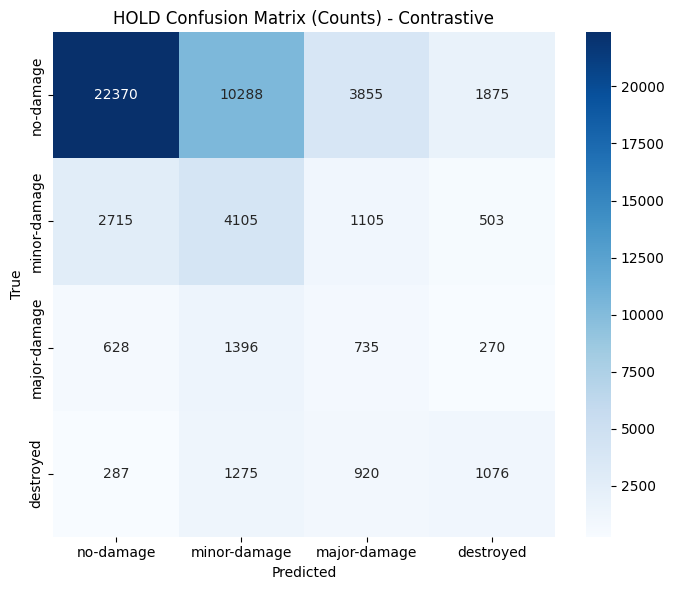

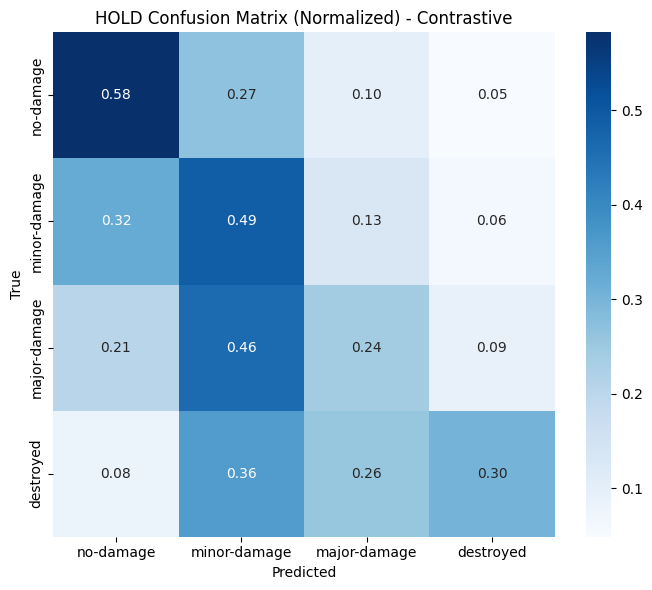

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from pathlib import Path

# =========================
# Configuration
# =========================

split = "hold"   # "test" or "hold"

labels = ["no-damage", "minor-damage", "major-damage", "destroyed"]

PROJECT_ROOT = Path.cwd()

# output folder
candidate_paths = [
    PROJECT_ROOT / "OOD_training_outputs" / "resnet50_contrastive",
    Path.home() / "Desktop" / "OOD_training_outputs" / "resnet50_supervised_contrastive",
]

BASE_PATH = None
y_true_path = None
y_pred_path = None

# =========================
# Search logic (robust)
# =========================

for path in candidate_paths:

    # 🔴 Contrastive naming (most likely)
    contrastive_true = path / f"ood_{split}_targets.npy"
    contrastive_pred = path / f"ood_{split}_preds.npy"

    # fallback naming (just in case)
    alt_true = path / f"{split}_targets.npy"
    alt_pred = path / f"{split}_preds.npy"

    if contrastive_true.exists() and contrastive_pred.exists():
        BASE_PATH = path
        y_true_path = contrastive_true
        y_pred_path = contrastive_pred
        print("Using contrastive naming")
        break

    elif alt_true.exists() and alt_pred.exists():
        BASE_PATH = path
        y_true_path = alt_true
        y_pred_path = alt_pred
        print("Using alternative naming")
        break

# =========================
# Fail clearly if not found
# =========================

if BASE_PATH is None:
    print("Files not found. Available .npy files:\n")
    for path in candidate_paths:
        if path.exists():
            print(f"\n{path}:")
            for f in path.glob("*.npy"):
                print("  ", f.name)

    raise FileNotFoundError("Could not find matching prediction files.")

print(f"\nUsing files:\n{y_true_path}\n{y_pred_path}")

# =========================
# Load predictions
# =========================

y_true = np.load(y_true_path)
y_pred = np.load(y_pred_path)

# =========================
# Confusion matrices
# =========================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title(f"{split.upper()} Confusion Matrix (Counts) - Contrastive")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# =========================
# Normalized version
# =========================

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title(f"{split.upper()} Confusion Matrix (Normalized) - Contrastive")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

Available splits in CSV:
split
OOD_train    166544
OOD_hold      53403
OOD_test      46833
Name: count, dtype: int64

Rows in selected CSV split: 53403
Predictions: 53403
Targets: 53403

Available image IDs:
Series([], Name: count, dtype: int64)

Selected image_id: hurricane-michael_00000003
Number of buildings in selected image: 35


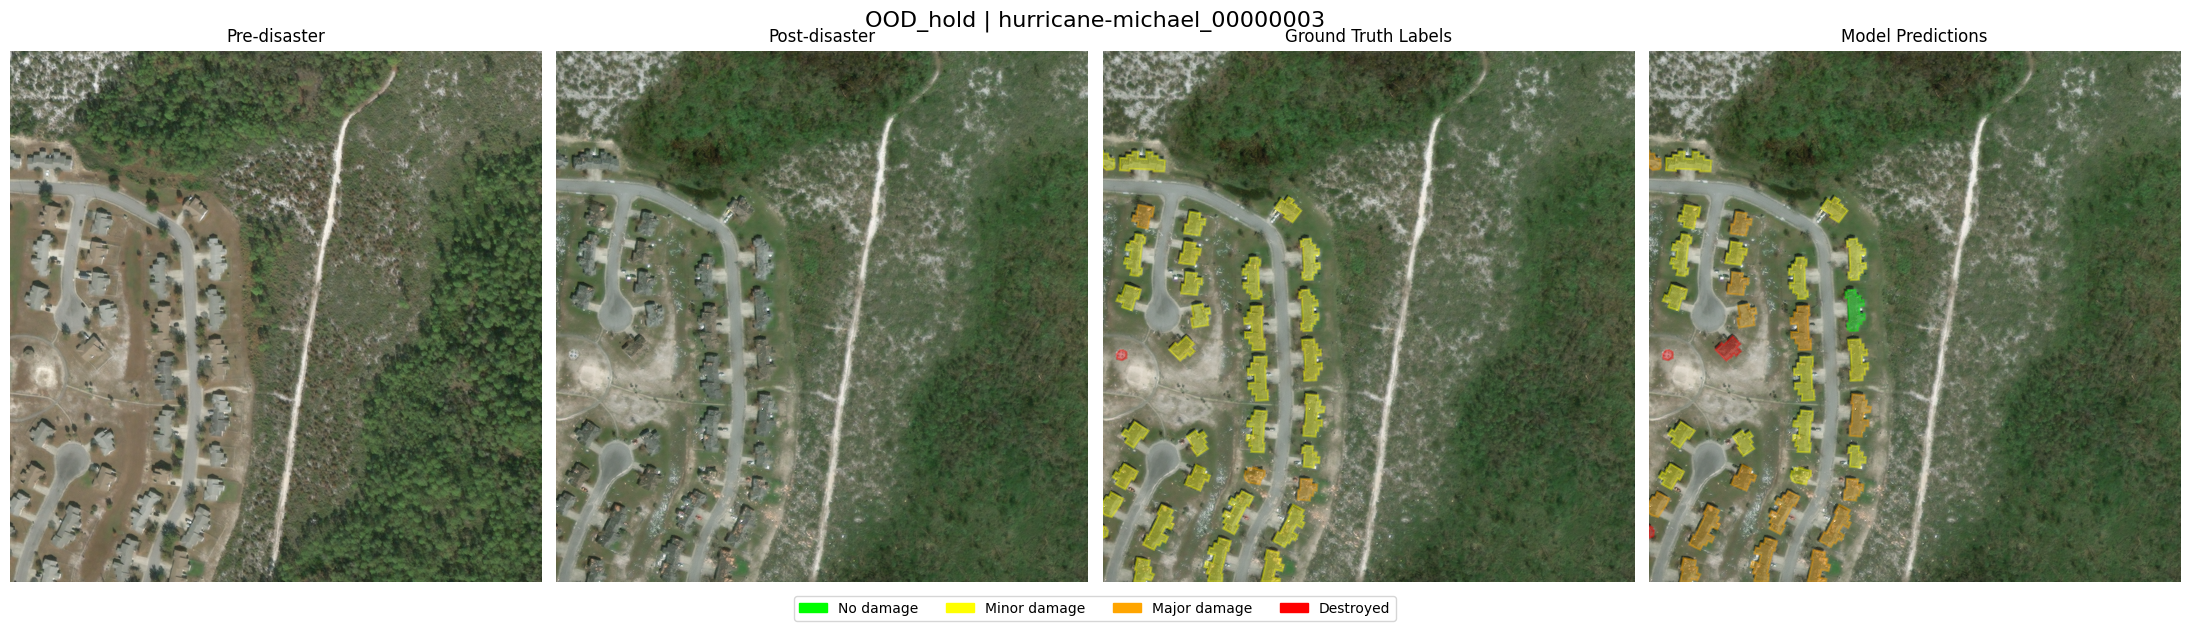

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely import wkt

# =========================
# Paths
# =========================
BASE_DIR = Path.home() / "Desktop"
CSV_PATH = BASE_DIR / "OOD_processed" / "buildings_all_OOD_with_crops.csv"
OUTPUT_DIR = BASE_DIR / "OOD_training_outputs" / "resnet50_supervised_contrastive"

# =========================
# Choose split
# =========================
# Your CSV uses: OOD_train, OOD_test, OOD_hold
CSV_SPLIT = "OOD_hold"

# Your prediction files use: ood_test_preds.npy, ood_hold_preds.npy
FILE_SPLIT = "hold"

# =========================
# Labels and colors
# =========================
LABELS = ["no-damage", "minor-damage", "major-damage", "destroyed"]

COLORS = {
    "no-damage": "lime",
    "minor-damage": "yellow",
    "major-damage": "orange",
    "destroyed": "red",
}

# =========================
# Load data
# =========================
df = pd.read_csv(CSV_PATH)

print("Available splits in CSV:")
print(df["split"].value_counts())

split_df = df[df["split"] == CSV_SPLIT].copy().reset_index(drop=True)

pred_path = OUTPUT_DIR / f"ood_{FILE_SPLIT}_preds.npy"
target_path = OUTPUT_DIR / f"ood_{FILE_SPLIT}_targets.npy"

if not pred_path.exists():
    raise FileNotFoundError(f"Missing prediction file: {pred_path}")

if not target_path.exists():
    raise FileNotFoundError(f"Missing target file: {target_path}")

preds = np.load(pred_path)
targets = np.load(target_path)

print("\nRows in selected CSV split:", len(split_df))
print("Predictions:", len(preds))
print("Targets:", len(targets))

if len(split_df) == 0:
    raise ValueError(
        f"No rows found for CSV_SPLIT='{CSV_SPLIT}'. "
        "Check the printed split names above and update CSV_SPLIT."
    )

if len(split_df) != len(preds):
    raise ValueError(
        f"Mismatch: selected CSV split has {len(split_df)} rows, "
        f"but predictions contain {len(preds)} values. "
        "CSV_SPLIT and FILE_SPLIT probably do not refer to the same split."
    )

if len(preds) != len(targets):
    raise ValueError(
        f"Mismatch: predictions contain {len(preds)} values, "
        f"but targets contain {len(targets)} values."
    )

# =========================
# Add predictions to dataframe
# =========================
split_df["pred_idx"] = preds
split_df["true_idx"] = targets
split_df["pred_label"] = split_df["pred_idx"].map(lambda i: LABELS[int(i)])
split_df["true_label"] = split_df["true_idx"].map(lambda i: LABELS[int(i)])

# =========================
# Select image
# =========================
counts = split_df["image_id"].value_counts()

print("\nAvailable image IDs:")
print(counts.head(0))

# Option A: automatically use the first available image
image_id = counts.index[520]


img_df = split_df[split_df["image_id"] == image_id].copy()

if img_df.empty:
    raise ValueError(f"No rows found for image_id='{image_id}'.")

print("\nSelected image_id:", image_id)
print("Number of buildings in selected image:", len(img_df))

# =========================
# Load images
# =========================
pre_path = Path(img_df.iloc[0]["pre_image_path"])
post_path = Path(img_df.iloc[0]["post_image_path"])

if not pre_path.exists():
    raise FileNotFoundError(f"Missing pre-disaster image: {pre_path}")

if not post_path.exists():
    raise FileNotFoundError(f"Missing post-disaster image: {post_path}")

pre = np.array(Image.open(pre_path))
post = np.array(Image.open(post_path))

# =========================
# Plotting helper
# =========================
def draw_polygons(ax, image, rows, label_col, title):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

    for _, row in rows.iterrows():
        poly = wkt.loads(row["wkt"])
        label = row[label_col]
        color = COLORS[label]

        x, y = poly.exterior.xy
        coords = list(zip(x, y))

        patch = mpatches.Polygon(
            coords,
            closed=True,
            fill=True,
            alpha=0.35,
            edgecolor=color,
            facecolor=color,
            linewidth=1.5,
        )
        ax.add_patch(patch)

# =========================
# Legend
# =========================
legend_elements = [
    mpatches.Patch(color=COLORS["no-damage"], label="No damage"),
    mpatches.Patch(color=COLORS["minor-damage"], label="Minor damage"),
    mpatches.Patch(color=COLORS["major-damage"], label="Major damage"),
    mpatches.Patch(color=COLORS["destroyed"], label="Destroyed"),
]

# =========================
# Plot
# =========================
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(pre)
axes[0].set_title("Pre-disaster")
axes[0].axis("off")

axes[1].imshow(post)
axes[1].set_title("Post-disaster")
axes[1].axis("off")

draw_polygons(
    axes[2],
    post,
    img_df,
    label_col="true_label",
    title="Ground Truth Labels",
)

draw_polygons(
    axes[3],
    post,
    img_df,
    label_col="pred_label",
    title="Model Predictions",
)

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.05),
)

plt.suptitle(f"{CSV_SPLIT} | {image_id}", fontsize=16)
plt.tight_layout()
plt.show()

In [12]:
from pathlib import Path

OUTPUT_DIR = Path.home() / "Desktop" / "OOD_training_outputs" / "resnet50_supervised_contrastive"

print(OUTPUT_DIR.exists())
print(list(OUTPUT_DIR.glob("*")))

True
[PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/summary.json'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/ood_hold_targets.npy'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/ood_hold_preds.npy'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/contrastive_latest.pt'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/ood_hold_confusion_matrix.npy'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/best_model.pt'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/contrastive_final.pt'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/contrastive_history.csv'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/ood_test_preds.npy'), PosixPath('/Users/p